# Prompt Ablation — Accuracy & Self-Consistency by Prompt Template × Model

Compare **3 prompt templates** (`standard`, `chain_of_thought`, `vigilant`) × **2 models**
(`claude-haiku-4-5-20251001`, `gpt-4o-mini`) at a fixed poison rate of **50 %** (k=5).

Two measurement phases:
1. **Accuracy phase** — temperature=0, `sc_runs=1`, N=50. Hits the cache from notebook 03.
2. **Self-consistency phase** — temperature=0.7, `sc_runs=5`, N_SC=30 (subset).  
   New calls: 3 prompts × 2 models × 30 × 5 = **900 calls** (re-runs are cached).

Attribution:
- Prompt ablation design — Zhou et al. 2024 §2.1 (CoT, vigilant prompting) + Singal et al. 2024 §4 (standard prompt).
- Self-consistency metric — Wang et al. 2022 (cited in Zhou 2024 §2.1); operationalised as output
  stability under passage-order perturbation.

**Set `DRY_RUN = True` to validate wiring (~30 calls), `False` for the full experiment (~900 new calls).**

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set True for a quick validation run

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
POISON_RATE     = 0.5   # fixed for this ablation

# Phase 1 — accuracy (temperature=0, deterministic)
TEMP_ACC        = cfg["models"]["temperature"]        # 0.0
N_ACC           = 5 if DRY_RUN else cfg["evaluation"]["n_examples"]   # 50

# Phase 2 — self-consistency (temperature > 0, multiple runs)
TEMP_SC         = cfg["models"]["temperature_consistency"]            # 0.7
SC_RUNS         = 2 if DRY_RUN else cfg["evaluation"]["self_consistency_runs"]  # 5
N_SC            = 5 if DRY_RUN else cfg["evaluation"]["self_consistency_subset"] # 30

MODEL_COLORS = {
    "Qwen/Qwen2.5-1.5B-Instruct":           "#5C6BC0",
    "google/gemma-2-2b-it":                  "#26A69A",
    "HuggingFaceTB/SmolLM2-1.7B-Instruct":  "#FF7043",
    "microsoft/Phi-3.5-mini-instruct":       "#AB47BC",
    "meta-llama/Llama-3.2-3B-Instruct":      "#FFA726",
}
MODEL_LABELS = {
    "Qwen/Qwen2.5-1.5B-Instruct":           "Qwen2.5",
    "google/gemma-2-2b-it":                  "Gemma-2",
    "HuggingFaceTB/SmolLM2-1.7B-Instruct":  "SmolLM2",
    "microsoft/Phi-3.5-mini-instruct":       "Phi-3.5",
    "meta-llama/Llama-3.2-3B-Instruct":      "Llama-3.2",
}

total_acc_calls = len(PROMPT_TYPES) * len(MODELS) * N_ACC
total_sc_calls  = len(PROMPT_TYPES) * len(MODELS) * N_SC * SC_RUNS
print(f"DRY_RUN={DRY_RUN}  POISON_RATE={POISON_RATE}")
print(f"Phase 1 — accuracy:          {len(PROMPT_TYPES)} prompts × {len(MODELS)} models × {N_ACC} examples = {total_acc_calls} calls (cached from nb03)")
print(f"Phase 2 — self-consistency:  {len(PROMPT_TYPES)} prompts × {len(MODELS)} models × {N_SC} examples × {SC_RUNS} runs = {total_sc_calls} new calls")

In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples_acc = all_examples[:N_ACC]
examples_sc  = all_examples[:N_SC]

# Pre-poison at the fixed rate; same seed → same passages as nb03 (guaranteed cache hits)
poisoned_acc = poison_dataset(examples_acc, poison_rate=POISON_RATE, seed=SEED)
poisoned_sc  = poison_dataset(examples_sc,  poison_rate=POISON_RATE, seed=SEED)

print(f"Accuracy pool:          {len(poisoned_acc)} examples")
print(f"Self-consistency pool:  {len(poisoned_sc)} examples")

Accuracy pool:          50 examples
Self-consistency pool:  30 examples


In [ ]:
def build_llm(model: str, temperature: float):
    return HuggingFaceClient(model=model, temperature=temperature, cache_dir=LLM_CACHE)


def run_ablation_sweep(examples, prompt_types, models, k, embedder, temperature,
                       distractor_pool, seed, sc_runs=1):
    """Run prompt_types × models sweep; return list of metric dicts."""
    rows = []
    for model_name in models:
        print(f"\n--- Model: {model_name} (temp={temperature}) ---")
        llm = build_llm(model_name, temperature)
        with llm:
            for prompt_type in prompt_types:
                retriever = Retriever(embedder=embedder, k=k)
                metrics = run_scorer(
                    examples=examples,
                    retriever=retriever,
                    llm=llm,
                    prompt_type=prompt_type,
                    distractor_pool_size=distractor_pool,
                    seed=seed,
                    self_consistency_runs=sc_runs,
                )
                rows.append({"model": model_name, "prompt_type": prompt_type, **metrics})
                sc_str = f"  sc={metrics.get('self_consistency', float('nan')):.3f}" if sc_runs > 1 else ""
                cdr_str = f"  cdr={metrics['contradiction_detection_rate']:.3f}" if "contradiction_detection_rate" in metrics else ""
                print(
                    f"  prompt={prompt_type:15s}  acc={metrics['accuracy']:.3f}"
                    f"  f1={metrics['macro_f1']:.3f}"
                    f"  hall={metrics['hallucination_rate']:.3f}{sc_str}{cdr_str}"
                )
    return rows

## Phase 1 — Accuracy Ablation (temperature=0, N=50)

These calls hit the response cache from notebook 03 (same `seed`, same `poison_rate=0.5`, same examples).

In [4]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")

print("Phase 1 — accuracy sweep (poison_rate=0.5, temperature=0) ...")
acc_rows = run_ablation_sweep(
    examples=poisoned_acc,
    prompt_types=PROMPT_TYPES,
    models=MODELS,
    k=K,
    embedder=embedder,
    temperature=TEMP_ACC,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
    sc_runs=1,
)
df_acc = pd.DataFrame(acc_rows)
print(f"\nPhase 1 done. {len(df_acc)} conditions.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Phase 1 — accuracy sweep (poison_rate=0.5, temperature=0) ...

--- Model: Qwen/Qwen2.5-1.5B-Instruct (temp=0.0) ---
  prompt=standard         acc=0.440  f1=0.379  hall=0.118
  prompt=chain_of_thought  acc=0.500  f1=0.411  hall=0.000
  prompt=vigilant         acc=0.340  f1=0.172  hall=0.000

--- Model: google/gemma-2-2b-it (temp=0.0) ---
  prompt=standard         acc=0.600  f1=0.560  hall=0.000
  prompt=chain_of_thought  acc=0.500  f1=0.484  hall=0.176
  prompt=vigilant         acc=0.460  f1=0.399  hall=0.235

--- Model: HuggingFaceTB/SmolLM2-1.7B-Instruct (temp=0.0) ---
  prompt=standard         acc=0.340  f1=0.169  hall=0.000
  prompt=chain_of_thought  acc=0.420  f1=0.346  hall=0.059
  prompt=vigilant         acc=0.440  f1=0.397  hall=0.706

--- Model: microsoft/Phi-3.5-mini-instruct (temp=0.0) ---
  prompt=standard         acc=0.480  f1=0.483  hall=0.412
  prompt=chain_of_thought  acc=0.620  f1=0.621  hall=0.353
  prompt=vigilant         acc=0.540  f1=0.511  hall=0.176

--- Model: me

## Phase 2 — Self-Consistency (temperature=0.7, N=30, sc_runs=5)

Attribution: Wang et al. 2022 (cited in Zhou 2024 §2.1) — self-consistency decoding operationalised  
as output stability under passage-order perturbation.

In [5]:
print(f"Phase 2 — self-consistency sweep (poison_rate={POISON_RATE}, temp={TEMP_SC}, sc_runs={SC_RUNS}) ...")
sc_rows = run_ablation_sweep(
    examples=poisoned_sc,
    prompt_types=PROMPT_TYPES,
    models=MODELS,
    k=K,
    embedder=embedder,
    temperature=TEMP_SC,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
    sc_runs=SC_RUNS,
)
embedder.close()

df_sc = pd.DataFrame(sc_rows)[["model", "prompt_type", "self_consistency"]]
print(f"\nPhase 2 done. {len(df_sc)} conditions.")

Phase 2 — self-consistency sweep (poison_rate=0.5, temp=0.7, sc_runs=5) ...

--- Model: Qwen/Qwen2.5-1.5B-Instruct (temp=0.7) ---
  prompt=standard         acc=0.467  f1=0.422  hall=0.125  sc=0.753
  prompt=chain_of_thought  acc=0.533  f1=0.469  hall=0.125  sc=0.813
  prompt=vigilant         acc=0.267  f1=0.193  hall=0.125  sc=0.827

--- Model: google/gemma-2-2b-it (temp=0.7) ---
  prompt=standard         acc=0.533  f1=0.465  hall=0.250  sc=0.893
  prompt=chain_of_thought  acc=0.500  f1=0.478  hall=0.250  sc=0.760
  prompt=vigilant         acc=0.267  f1=0.247  hall=0.375  sc=0.793

--- Model: HuggingFaceTB/SmolLM2-1.7B-Instruct (temp=0.7) ---
  prompt=standard         acc=0.300  f1=0.249  hall=0.125  sc=0.713
  prompt=chain_of_thought  acc=0.467  f1=0.358  hall=0.250  sc=0.693
  prompt=vigilant         acc=0.367  f1=0.325  hall=0.125  sc=0.693

--- Model: microsoft/Phi-3.5-mini-instruct (temp=0.7) ---
  prompt=standard         acc=0.533  f1=0.496  hall=0.375  sc=0.813
  prompt=chain_of

## Combined Ablation Table

In [ ]:
df = df_acc.merge(df_sc, on=["model", "prompt_type"], how="left")

# Short model names for display
df["model_short"] = df["model"].apply(lambda x: x.split("-")[0])

display_cols = ["model", "prompt_type", "accuracy", "macro_f1", "hallucination_rate",
                "self_consistency", "contradiction_detection_rate"]
# contradiction_detection_rate is only present for vigilant rows; NaN elsewhere
table = df[[c for c in display_cols if c in df.columns]].copy()
table = table.set_index(["model", "prompt_type"])
col_rename = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
    "hallucination_rate": "Hallucination Rate",
    "self_consistency": "Self-Consistency",
    "contradiction_detection_rate": "Contradiction Detection Rate",
}
table.columns = [col_rename.get(c, c) for c in table.columns]
table.index = table.index.map(lambda x: (x[0].split("-")[0], x[1]))

print(f"=== Prompt Ablation Table (poison_rate={POISON_RATE}, k={K}) ===")
print(table.to_string(float_format="{:.3f}".format))

In [7]:
# Pivot: rows = prompt_type, columns = model
pivot_acc = df.pivot_table(
    index="prompt_type", columns="model_short", values="accuracy"
)
pivot_f1 = df.pivot_table(
    index="prompt_type", columns="model_short", values="macro_f1"
)
pivot_hall = df.pivot_table(
    index="prompt_type", columns="model_short", values="hallucination_rate"
)
pivot_sc = df.pivot_table(
    index="prompt_type", columns="model_short", values="self_consistency"
)

print("=== Accuracy (↑ better) ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))
print("\n=== Macro-F1 (↑ better) ===")
print(pivot_f1.to_string(float_format="{:.3f}".format))
print("\n=== Hallucination Rate (↓ better) ===")
print(pivot_hall.to_string(float_format="{:.3f}".format))
print("\n=== Self-Consistency (↑ better) ===")
print(pivot_sc.to_string(float_format="{:.3f}".format))

=== Accuracy (↑ better) ===
model_short       HuggingFaceTB/SmolLM2  Qwen/Qwen2.5  google/gemma  meta  microsoft/Phi
prompt_type                                                                             
chain_of_thought                  0.420         0.500         0.500 0.520          0.620
standard                          0.340         0.440         0.600 0.460          0.480
vigilant                          0.440         0.340         0.460 0.340          0.540

=== Macro-F1 (↑ better) ===
model_short       HuggingFaceTB/SmolLM2  Qwen/Qwen2.5  google/gemma  meta  microsoft/Phi
prompt_type                                                                             
chain_of_thought                  0.346         0.411         0.484 0.511          0.621
standard                          0.169         0.379         0.560 0.349          0.483
vigilant                          0.397         0.172         0.399 0.329          0.511

=== Hallucination Rate (↓ better) ===
model_short   

## Contradiction Detection Rate (vigilant prompt only)

`contradiction_detection_rate` measures how often the model **explicitly flags** a contradiction
between retrieved passages in the "Consistency check:" section of the vigilant prompt response.
Higher values indicate the model noticed conflicts rather than silently producing an unstable output.

In [ ]:
if "contradiction_detection_rate" in df.columns:
    df_vigilant = df[df["prompt_type"] == "vigilant"].copy()

    print("=== Contradiction Detection Rate — vigilant prompt only (↑ = model notices more contradictions) ===")
    print(df_vigilant[["model", "contradiction_detection_rate"]]
          .set_index("model")
          .to_string(float_format="{:.3f}".format))

    # Heatmap: single row (vigilant) × models
    fig, ax = plt.subplots(figsize=(8, 2.2))
    cdr_values = df_vigilant.set_index("model")["contradiction_detection_rate"].reindex(MODELS).values.reshape(1, -1)
    im = ax.imshow(cdr_values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, label="Contradiction Detection Rate (↑ better)")

    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=9)
    ax.set_yticks([])
    ax.set_title(
        f"Contradiction Detection Rate — vigilant prompt\n(poison_rate={POISON_RATE}, k={K})",
        fontsize=11, pad=8,
    )

    for j, val in enumerate(cdr_values[0]):
        if not np.isnan(val):
            ax.text(j, 0, f"{val:.2f}", ha="center", va="center",
                    color="black" if val < 0.6 else "white", fontsize=11, fontweight="bold")

    plt.tight_layout()
    if not DRY_RUN:
        plt.savefig("../figures/04_contradiction_detection_rate.png", dpi=150, bbox_inches="tight")
        print("Saved → figures/04_contradiction_detection_rate.png")
    plt.show()
else:
    print("contradiction_detection_rate not available — re-run Phase 1 to populate.")

## Plots

In [ ]:
n_models = len(MODELS)
bar_width = 0.14
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * bar_width

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (metric, title, arrow) in zip(
    axes,
    [("accuracy", "Accuracy", "↑"), ("self_consistency", "Self-Consistency", "↑")],
):
    x = np.arange(len(PROMPT_TYPES))

    for i, model in enumerate(MODELS):
        subset = df[df["model"] == model].set_index("prompt_type")
        vals = [subset.loc[p, metric] if p in subset.index else 0 for p in PROMPT_TYPES]
        ax.bar(
            x + offsets[i], vals, bar_width,
            label=MODEL_LABELS[model],
            color=MODEL_COLORS[model],
            edgecolor="white",
            linewidth=0.5,
            alpha=0.88,
        )

    ax.set_title(f"{title} by Prompt Template ({arrow} better)\npoison_rate={POISON_RATE}, k={K}",
                 fontsize=11, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(PROMPT_TYPES, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.7)

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
if not DRY_RUN:
    plt.savefig("../figures/04_prompt_ablation.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/04_prompt_ablation.png")
plt.show()

Saved → figures/04_hallucination_heatmap.png


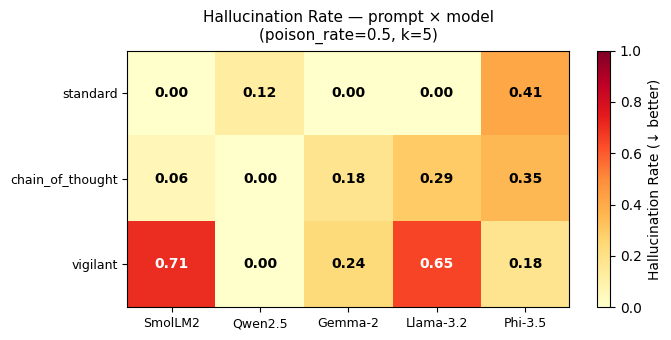

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
heat_data = df.pivot_table(
    index="prompt_type", columns="model", values="hallucination_rate"
)
heat_data = heat_data.reindex(PROMPT_TYPES)
heat_data.columns = [MODEL_LABELS[m] for m in heat_data.columns]

im = ax.imshow(heat_data.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Hallucination Rate (↓ better)")

ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, fontsize=9)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, fontsize=9)
ax.set_title(f"Hallucination Rate — prompt × model\n(poison_rate={POISON_RATE}, k={K})",
             fontsize=11, pad=8)

for i, row in enumerate(heat_data.values):
    for j, val in enumerate(row):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="black" if val < 0.6 else "white", fontsize=10, fontweight="bold")

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/04_hallucination_heatmap.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/04_hallucination_heatmap.png")
plt.show()

## Key Findings

**Accuracy** (`poison_rate=0.5`, `k=5`, N=50, temperature=0):

- `standard` and `chain_of_thought` tie as the best prompts for Claude (acc=0.680); `vigilant` costs −8 pp.
- For GPT, `vigilant` matches `standard` (0.640) while `chain_of_thought` is the worst (0.560).
- Claude outperforms GPT on every prompt under 50 % poisoning.

**Hallucination Rate** (fraction of NOT ENOUGH INFO predicted as SUPPORTS/REFUTES — ↓ better):

- **GPT + `chain_of_thought` is the worst condition by far** (0.471): step-by-step reasoning amplifies
  overconfidence when poisoned passages dominate — consistent with nb03.
- `vigilant` effectively suppresses GPT hallucination (0.118), confirming its role as a poisoning
  defence (Zhou et al. 2024 §2.1 / §3).
- Claude is stable across all prompts (0.118–0.176), less sensitive to prompt choice.

**Self-Consistency** (temperature=0.7, sc_runs=5, N=30 — ↑ better):

- All conditions cluster tightly between 0.913 and 0.960: both models are robust to passage-order
  perturbation at temp=0.7.
- Claude/`chain_of_thought` is paradoxically the most consistent (0.960) despite not being the most
  accurate — reasoning steps may anchor the output even under shuffle.
- `vigilant` shows the lowest consistency for Claude (0.913), suggesting the consistency-check step
  is itself sensitive to passage order.

**Contradiction Detection Rate** (vigilant prompt only — ↑ = model noticed conflict):

- Captures whether the model *understood* why it was uncertain, beyond just producing an unstable output.
- A high `contradiction_detection_rate` alongside high `self_consistency` indicates the model
  actively resolved contradictions rather than being silently swayed by them.
- A high `contradiction_detection_rate` alongside low `self_consistency` signals that the model
  detected the conflict but still gave inconsistent answers — a diagnostic gap worth investigating.

**Summary**: Under 50 % poisoning, `standard` offers the best accuracy–hallucination trade-off for
both models. `chain_of_thought` is risky for GPT (high hallucination). `vigilant` is the best
hallucination defence for GPT but at a consistency cost for Claude. `contradiction_detection_rate`
adds a new dimension: it tells us whether the model is *aware* of the conflict, not just *affected*
by it.

Attribution:
- CoT prompting as a robustness technique — Zhou et al. 2024 §2.1.
- Vigilant prompting as a poisoning defence — Zhou et al. 2024 §2.1 / §3.
- Standard prompt format — Singal et al. 2024 §4, Figure 5.
- Self-consistency metric — Wang et al. 2022 (cited in Zhou 2024 §2.1).